In [1]:
# Imports

import helpers.helper_functions as hf
import mne
import os.path as op
from mne.channels import combine_channels
import pandas as pd
from mne.beamformer import make_lcmv, apply_lcmv_epochs
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import hilbert
import helpers.test_circ_plot as circ_plot
import gc
import helpers.stc_helper as stc_helper
import time
from pycircstat2.hypothesis import rayleigh_test
from mne.stats import permutation_t_test
from mne.stats import fdr_correction
import nibabel as nib


ss = hf.settings_dict()

In [2]:
# Permutation settings
n_permutations = 2**ss['n_subjects']
alpha          = 0.05   # FDR threshold

results_dir = Path(ss["results_dir"])
results_dir.mkdir(parents=True, exist_ok=True)

from mne import spatial_src_adjacency
from mne.stats import permutation_cluster_1samp_test
from scipy.stats import t, ranksums

stim_tmin = 0.7
stim_tmax = 3.7 - (1/ss['fs'])
base_tmin = -0.5 + (1/ss['fs'])
base_tmax = 0.0



In [3]:
def morph_stc(stc, subject_index):
    subject_id = ss['subject_id_list'][subject_index]

    # name stuff
    morph_fname = op.join(ss['morph_dir'], subject_id+'-morph.h5')

    subject_morph_stat_dir = op.join(ss['stc_dir'], 'subject_morph_stat')
    morph = mne.read_source_morph(morph_fname)  # morph file

    morph_img = morph.apply(stc, mri_resolution=False, output='nifti1')

    morph_data = morph_img.get_fdata().copy()
    if subject_index == 8:
        morph_data = np.roll(morph_data, -5, axis = 1)  # fix displacement issue

    return morph_data

In [4]:
morph_data_list = []

for subject_index in ss['subject_idx_list']:
    subject = ss['subject_id_list'][subject_index]
    print("loading dataset for subject: ", subject)

    z_stats = []
    p_vals = []
    for event_id in ss['event_id_list']:
        event_name = str(event_id)
        print("loading event: ", event_name)

        # load stc data
        stcs = []

        for i in range(ss['n_trials']):
            stc_fname = Path(ss['stc_unaveraged_dir']) / subject / event_name / f"{subject}-{i}-vol.stc"
            stc = mne.read_source_estimate(stc_fname)
            stcs.append(stc)

        stim_stc_data = []
        base_stc_data = []

        for stc in stcs:
            stim_stc = stc.copy().crop(tmin=stim_tmin, tmax=stim_tmax)
            stim_stc_data.append(stim_stc.data)

            base_stc = stc.copy().crop(tmin=base_tmin, tmax=base_tmax)
            base_stc_data.append(base_stc.data)

        stim_stc_data = np.stack(stim_stc_data)
        base_stc_data = np.stack(base_stc_data)

        n_voxels, n_times = stcs[0].data.shape

        z_stat = np.zeros(n_voxels)
        p_val = np.zeros(n_voxels)

        # Rayleigh test to get z-scores

        rms_base = np.sqrt(np.mean(np.square(base_stc_data), axis=0))
        rms_stim = np.sqrt(np.mean(np.square(stim_stc_data), axis=0))

        for voxel_idx in range(n_voxels):
            result = ranksums(rms_stim[voxel_idx], rms_base[voxel_idx])
            z_stat[voxel_idx] = result.statistic
            p_val[voxel_idx] = result.pvalue

        z_stats.append(z_stat)
        p_vals.append(p_val)


    z_stc       = stcs[0].copy().crop(0.0, 0.0 + (ss['n_events']-1)/ss['fs'])
    z_stc.data  = np.array(z_stats).T

    morph_z_data = morph_stc(z_stc, subject_index)

    morph_data_list.append(morph_z_data)      # (n_voxels,)

    del stcs

loading dataset for subject:  0005_3SJ
loading event:  1
loading event:  2
loading event:  3
loading event:  4
loading event:  5
loading event:  6
loading event:  7


  0%|          | Time : 0/7 [00:00<?,       ?it/s]

loading dataset for subject:  0002_TCZ
loading event:  1
loading event:  2
loading event:  3
loading event:  4
loading event:  5
loading event:  6
loading event:  7


  0%|          | Time : 0/7 [00:00<?,       ?it/s]

loading dataset for subject:  0009_YGZ
loading event:  1
loading event:  2
loading event:  3
loading event:  4
loading event:  5
loading event:  6
loading event:  7


...

  0%|          | Time : 0/7 [00:00<?,       ?it/s]

loading dataset for subject:  0018_5T3
loading event:  1
loading event:  2
loading event:  3
loading event:  4
loading event:  5
loading event:  6
loading event:  7


  0%|          | Time : 0/7 [00:00<?,       ?it/s]

loading dataset for subject:  0019_COG
loading event:  1
loading event:  2
loading event:  3
loading event:  4
loading event:  5
loading event:  6
loading event:  7


  0%|          | Time : 0/7 [00:00<?,       ?it/s]

In [5]:

#% Make mask of locations with z-values across all data.
mask_img = nib.load(op.join(ss['atlas_dir'], 'empty_10mm.nii'))
mask = np.ones(mask_img.shape[0:3])

for morph_data in morph_data_list:
    for event in range(ss['n_events']):
        mask[morph_data[:,:,:,event] == 0.00] = 0

for event in range(ss['n_events']):
    mask_img.get_fdata()[:,:,:,event] = mask

#nib.save(mask_img, op.join(atlas_dir, stc_version+'_mask_10mm.nii'))
mask_flat = mask.flatten()

print(np.sum(mask==1))


from mne.stats import permutation_t_test

#from mlxtend.evaluate import permutation_test

#zero_mean = np.zeros(12)
n_sources = int(np.sum(mask))
n_subjects = len(morph_data_list)
#n_events = ss['n_events']
tval = np.zeros([ss['n_events'], n_sources])
pval = np.zeros([ss['n_events'], n_sources])
n_permutations = 2**n_subjects

import time
tstart = time.time()

print("Perm. test. starting...")
for event in range(ss['n_events']):
    sample = np.zeros([n_subjects, n_sources])
    for subject in range(n_subjects):
        data_flat = morph_data_list[subject][:,:,:,event].flatten()
        sample[subject, :] = data_flat[mask_flat == 1]
        tval[event, :], pval[event, :], H0 = permutation_t_test(sample, n_permutations, n_jobs=1)
#
tend = time.time()
print('Done! Run time: '+str(int(tend - tstart))+' seconds')



2340
Perm. test. starting...
Permuting 2047 times (exact test)...
Permuting 2047 times (exact test)...
Permuting 2047 times (exact test)...
Permuting 2047 times (exact test)...
Permuting 2047 times (exact test)...
Permuting 2047 times (exact test)...
Permuting 2047 times (exact test)...
Permuting 2047 times (exact test)...
Permuting 2047 times (exact test)...
Permuting 2047 times (exact test)...
Permuting 2047 times (exact test)...
Permuting 2047 times (exact test)...
Permuting 2047 times (exact test)...
Permuting 2047 times (exact test)...
Permuting 2047 times (exact test)...
Permuting 2047 times (exact test)...
Permuting 2047 times (exact test)...
Permuting 2047 times (exact test)...
Permuting 2047 times (exact test)...
Permuting 2047 times (exact test)...
Permuting 2047 times (exact test)...
Permuting 2047 times (exact test)...
Permuting 2047 times (exact test)...
Permuting 2047 times (exact test)...
Permuting 2047 times (exact test)...
Permuting 2047 times (exact test)...
Permuting

In [6]:

tval_img = nib.load(op.join(ss['atlas_dir'], 'empty_10mm.nii'))
bool_perm_img = nib.load(op.join(ss['atlas_dir'], 'empty_10mm.nii'))
comb_img = nib.load(op.join(ss['atlas_dir'], 'empty_10mm.nii'))

tval_data = np.zeros(tval_img.get_fdata().shape)
bool_perm_data = np.zeros(bool_perm_img.get_fdata().shape)
comb_data = np.zeros(comb_img.get_fdata().shape)

bool_perm = pval <= 0.05

for event in range(ss['n_events']):
    tval_data[:,:,:,event][mask==1] = tval[event,:]
    bool_perm_data[:,:,:,event][mask==1] = bool_perm[event,:]

bool_perm_data2 = bool_perm_data.copy()
bool_perm_data2[tval_data<0] = 0

comb_data[bool_perm_data==1] = tval_data[bool_perm_data==1]

tval_img.get_fdata()[:,:,:,:] = tval_data
bool_perm_img.get_fdata()[:,:,:,:] = bool_perm_data
comb_img.get_fdata()[:,:,:,:] = comb_data


act_vol = np.sum(bool_perm_data2 == 1, axis=(0,1,2))
act_frac = act_vol/n_sources






/tmp/ipykernel_147678/1726975980.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ss['event_name_list'], rotation=45)


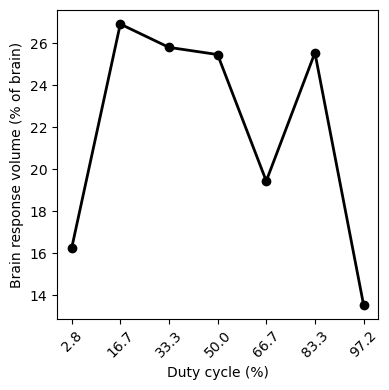

In [7]:
#stc_version = 'v003'
stc_version_list = ['v001']
#plt.close('all')
#plt.figure()
for stc_version in stc_version_list[:]:
    act_frac_p = [100 * act_frac[ii] / act_frac[3] for ii in range(len(act_frac))]

    x = [float(event_name) for event_name in ss['event_name_list']]
    x = range(7)
    fig, ax = plt.subplots(figsize=(4, 4))

    plt.plot(x, act_frac * 100, '-o', c='k', lw=2)
    #    plt.bar(x, act_frac*100, color = 'k',width=.7)
    #    plt.bar(x, act_frac)

    ax.set_xlabel('Duty cycle (%)')
    ax.set_xticklabels(ss['event_name_list'], rotation=45)
    ax.set_xticks(x)
    ax.set_ylabel('Brain response volume (% of brain)')
#    ax.set_xlim(0, 100)
plt.tight_layout()